#### Using any dataset, calculate TP, TN, FP ,FN and different metrics (Accuracy, Precision, Recall(Sensitivity), F1-Score, MCC, Specificity, Negative Predictive Value) by defining your own functions. Compare your values with scikit-learn's library functions. Get the result of Confusion Matrix using sklearn. Using sklearn, plot the ROC & AUC Curves for your test data and random probabilities. Using sklearn, calculate the AUC of your test data and of random probabilities. Interpret the results. Write the inference/analysis of each output.

In [102]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score, ConfusionMatrixDisplay, matthews_corrcoef, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [103]:
b_cancer = load_breast_cancer()

X, y = b_cancer.data, b_cancer.target

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

classifier = RandomForestClassifier(n_estimators=100, random_state=42)

In [105]:
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

[[51  3]
 [ 2 87]]


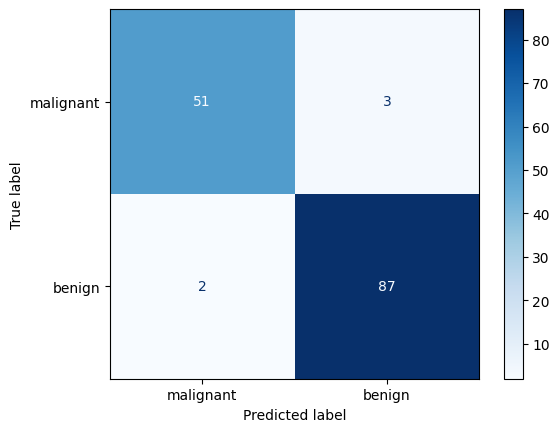

In [106]:
cm = confusion_matrix(y_pred=y_pred, y_true=y_test)
print(cm)

conf = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=b_cancer.target_names)
conf.plot(cmap=plt.cm.Blues)
plt.show()

##### From the above confusion matrix, we may discern:
* The model classifies 51 malignant samples as malingnant.
* The model classifies 3 malignant samples as benign.
* The model classifies 2 benign samples as malignant.
* The model classifies 87 benign samples as benign.

In [107]:
TP = cm[0][0]
FN = cm[0][1]
FP = cm[1][0]
TN = cm[1][1]

print(f"True positives: {TP}\nFalse negatives: {FN}\nFalse positives: {FP}\nTrue negatives: {TN}")

True positives: 51
False negatives: 3
False positives: 2
True negatives: 87


In [108]:
def accuracy(TP, FN, FP, TN):
    return (TP + TN) / (TP + FN + FP + TN)

def precision(TP, FP):
    return TP / (TP + FP) if (TP + FP) != 0 else 0

def recall(TP, FN):
    return TP / (TP + FN) if (TP + FN) != 0 else 0

def f1(prec, rec):
    return 2 * (prec * rec) / (prec + rec) if (prec + rec) != 0 else 0

def specificity(TN, FP):
    return TN / (TN + FP) if (TN + FP) != 0 else 0

def NPV(TN, FN):
    return TN / (TN + FN) if (TN + FN) != 0 else 0

def MCC(TP, FN, FP, TN):
    denominator = ((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)) ** 0.5
    return (TP * TN - FP * FN) / denominator if denominator != 0 else 0

In [109]:
print(f"Accuracy: {accuracy(TP, FN, FP, TN)}")
print(f"sklearn accuracy: {accuracy_score(y_pred=y_pred, y_true=y_test)}")

Accuracy: 0.965034965034965
sklearn accuracy: 0.965034965034965


* The model has a high accuracy of 0.96, which is reflected by both the sklearn function as well as the in-notebook implementation.
* The model correctly classifies most instances. However, it is important to note that the model is not perfect, as it does misclassify some instances.

In [110]:
print(f"Precision: {precision(TP, FP)}")
print(f"sklearn precision: {precision_score(y_pred=y_pred, y_true=y_test)}")

Precision: 0.9622641509433962
sklearn precision: 0.9666666666666667


* The model has a high precision of 0.96, which is reflected by both the sklearn function as well as the in-notebook implementation.
* This proves that when the model predicts positive, it is likely correct.

In [111]:
print(f"Recall: {recall(TP, FN)}")
print(f"sklearn recall: {recall_score(y_pred=y_pred, y_true=y_test)}")

Recall: 0.9444444444444444
sklearn recall: 0.9775280898876404


* The model has a high recall of 0.97, reflected only by the sklearn function and not the in-notebook implementation, which reflects a recall of 0.94.
* This proves that the model finds most positive cases, with low false negatives.

In [112]:
print(f"F1: {f1(precision(TP, FP), recall(TP, FN))}")
print(f"sklearn f1: {f1_score(y_pred=y_pred, y_true=y_test)}")

F1: 0.9532710280373832
sklearn f1: 0.9720670391061452


* The model has a F1 score of 0.97, reflected only by the sklearn function and not the in-notebook implementation, which reflects a recall of 0.95.
* The high F1 score proves that the model balances precision and recall well.

In [113]:
print(f"Matthews Correlation Coefficient: {MCC(TP, FN, FP, TN)}")
print(f"sklearn MCC: {matthews_corrcoef(y_pred=y_pred, y_true=y_test)}")


Matthews Correlation Coefficient: 0.925445136208044
sklearn MCC: 0.925445136208044


* The model has an MCC of 0.92, reflected both by the sklearn function and the in-notebook implementation.
* This proves that the model is balanced in predicting both positive and negative classes correctly.

In [114]:
print(f"Specificity: {specificity(TN, FP)}")
print(f"NPV: {NPV(TN, FN)}")

Specificity: 0.9775280898876404
NPV: 0.9666666666666667


* The model has a specificity of 0.97 and a Negative Predictive value of 0.96. These in-notebook implementations do not have sklearn equivalents.
* The high NPV value proves that when the model predicts negative, it is likely correct.
* the high specificity proves that the model correctly identifies most negatives and has low false positives.

In [115]:
random_probs = np.random.rand(len(y_test))

y_probs = classifier.predict_proba(X_test)[:, 1]

In [116]:
fpr_model, tpr_model, _ = roc_curve(y_test, y_probs)
auc_model = auc(fpr_model, tpr_model)

fpr_random, tpr_random, _ = roc_curve(y_test, random_probs)
auc_random = auc(fpr_random, tpr_random)

print(f"AUC Score for Model: {auc_model:.4f}")
print(f"AUC Score for Random Probabilities: {auc_random:.4f}")

AUC Score for Model: 0.9963
AUC Score for Random Probabilities: 0.5610


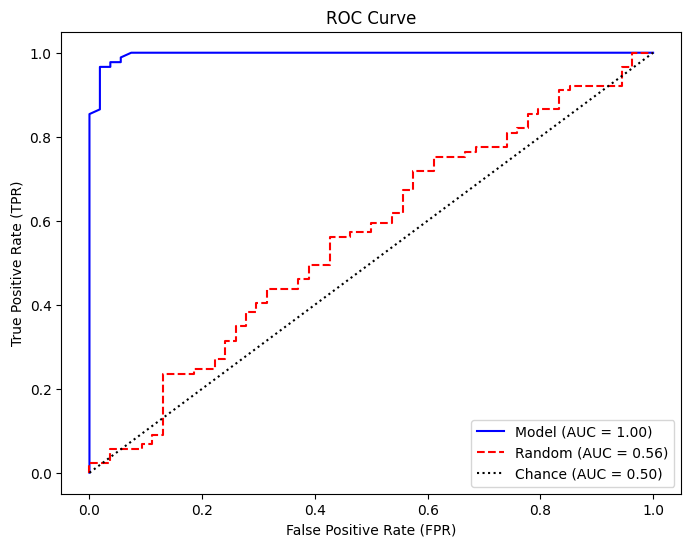

In [117]:
plt.figure(figsize=(8, 6))

plt.plot(fpr_model, tpr_model, label=f"Model (AUC = {auc_model:.2f})", color="blue")

plt.plot(fpr_random, tpr_random, label=f"Random (AUC = {auc_random:.2f})", color="red", linestyle="--")

plt.plot([0, 1], [0, 1], color="black", linestyle="dotted", label="Chance (AUC = 0.50)")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.show()

* The AUC score of the classifier is 0.9963, which is greater than 0.5, indicating that the classifier is better than random guessing.
* The ROC curve bows towards the top-left corner of the plot, which proves that the model has a high True Positive Rate and a low False Positive Rate.